In [1]:
!pip install -q cython

%load_ext cython

In [7]:
%%cython

cdef extern from *:
    """
    #define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION
    """

import numpy as np
cimport numpy as cnp
cimport cython
from libc.math cimport sqrt
import warnings
warnings.filterwarnings('ignore')

# نوع‌دهی دقیق برای حداکثر سرعت
ctypedef cnp.float64_t DTYPE_t
ctypedef cnp.int64_t INT_t

@cython.boundscheck(False)
@cython.wraparound(False)
@cython.cdivision(True)
def euclidean_dist_cython(cnp.ndarray[DTYPE_t, ndim=2] X_train,
                          cnp.ndarray[DTYPE_t, ndim=1] x_test):
    """
    محاسبه فاصله اقلیدسی یک نمونه تست با همه نمونه‌های train
    خیلی سریع‌تر از نسخه پایتون خالص
    """
    cdef int n_samples = X_train.shape[0]
    cdef int n_features = X_train.shape[1]
    cdef cnp.ndarray[DTYPE_t, ndim=1] distances = np.empty(n_samples, dtype=np.float64)

    cdef int i, j
    cdef DTYPE_t diff, total

    for i in range(n_samples):
        total = 0.0
        for j in range(n_features):
            diff = X_train[i, j] - x_test[j]
            total += diff * diff
        distances[i] = sqrt(total)

    return distances

@cython.boundscheck(False)
@cython.wraparound(False)
def predict_knn_cython(cnp.ndarray[DTYPE_t, ndim=2] X_train,
                       cnp.ndarray[INT_t, ndim=1] y_train,
                       cnp.ndarray[DTYPE_t, ndim=2] X_test,
                       int k=5):
    """
    KNN کاملاً دستی و بهینه‌شده با Cython
    """
    cdef int n_test = X_test.shape[0]
    cdef cnp.ndarray[INT_t, ndim=1] predictions = np.empty(n_test, dtype=np.int64)

    cdef cnp.ndarray[DTYPE_t, ndim=1] distances
    cdef cnp.ndarray[INT_t, ndim=1] indices
    cdef cnp.ndarray[INT_t, ndim=1] neighbor_labels
    cdef int i

    for i in range(n_test):
        distances = euclidean_dist_cython(X_train, X_test[i])
        indices = np.argpartition(distances, k)[:k]  # فقط k نزدیک‌ترین
        neighbor_labels = y_train[indices]
        predictions[i] = np.bincount(neighbor_labels).argmax()  # رای‌گیری

    return predictions

In [8]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Load dataset
bc = load_breast_cancer()
data = pd.DataFrame(data=np.c_[bc['data'], bc['target']],
                    columns=np.append(bc['feature_names'], 'target'))

x_train, x_test, y_train, y_test = train_test_split(
    bc.data, bc.target, test_size=0.2, random_state=42, stratify=bc.target
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# تبدیل به نوع مناسب برای Cython
X_train_cy = np.asarray(x_train_scaled, dtype=np.float64)
X_test_cy = np.asarray(x_test_scaled, dtype=np.float64)
y_train_cy = np.asarray(y_train, dtype=np.int64)

In [9]:
from sklearn.neighbors import KNeighborsClassifier
import time

print("=== مقایسه سرعت KNN ===")

# 1. scikit-learn KNN
start = time.time()
knn_sk = KNeighborsClassifier(n_neighbors=5)
knn_sk.fit(x_train_scaled, y_train)
pred_sk = knn_sk.predict(x_test_scaled)
time_sk = time.time() - start
print(f"scikit-learn KNN: {time_sk:.4f} ثانیه")

# 2. Cython KNN
start = time.time()
pred_cy = predict_knn_cython(X_train_cy, y_train_cy, X_test_cy, k=5)
time_cy = time.time() - start
print(f"Cython KNN: {time_cy:.4f} ثانیه")

# 3. پایتون خالص (برای مقایسه - کندتره)
def predict_knn_pure(X_train, y_train, X_test, k=5):
    predictions = []
    for x_test in X_test:
        distances = np.sqrt(((X_train - x_test) ** 2).sum(axis=1))
        nearest = np.argpartition(distances, k)[:k]
        pred = np.bincount(y_train[nearest]).argmax()
        predictions.append(pred)
    return np.array(predictions)

start = time.time()
pred_pure = predict_knn_pure(X_train_cy, y_train_cy, X_test_cy, k=5)
time_pure = time.time() - start
print(f"پایتون خالص KNN: {time_pure:.4f} ثانیه")

# دقت همه باید یکسان باشه
acc_sk = accuracy_score(y_test, pred_sk)
acc_cy = accuracy_score(y_test, pred_cy)
acc_pure = accuracy_score(y_test, pred_pure)
print(f"دقت: scikit-learn={acc_sk:.4f}, Cython={acc_cy:.4f}, Pure={acc_pure:.4f}")

=== مقایسه سرعت KNN ===
scikit-learn KNN: 0.0071 ثانیه
Cython KNN: 0.0111 ثانیه
پایتون خالص KNN: 0.0102 ثانیه
دقت: scikit-learn=0.9561, Cython=0.9561, Pure=0.9561


.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

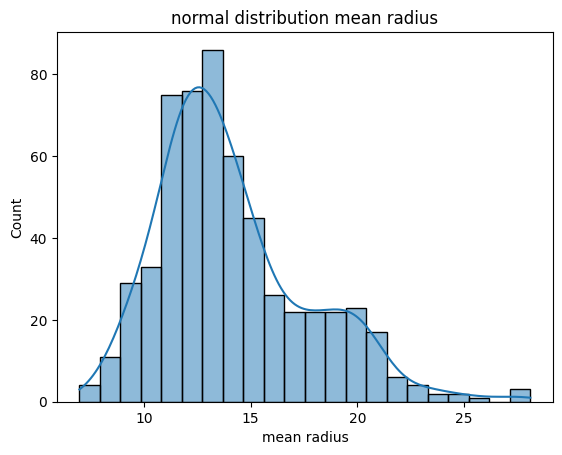

نسبت واریانس اصلی: [0.98204467 0.01617649]


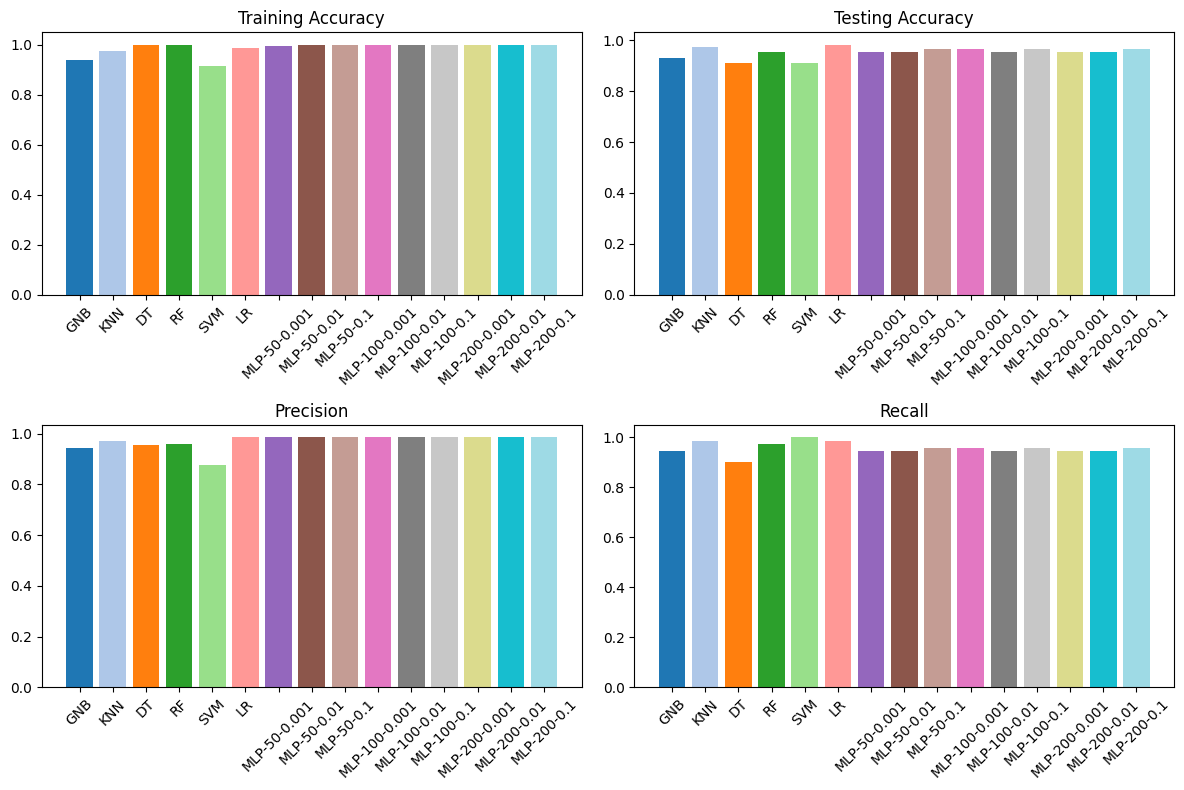

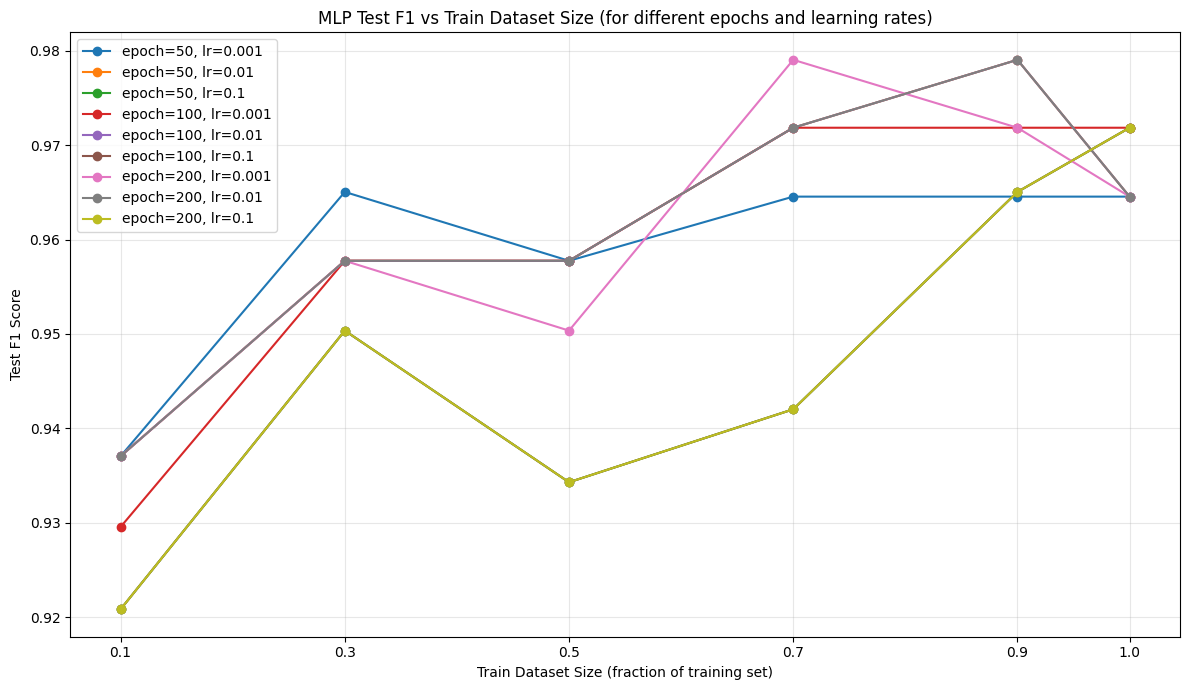

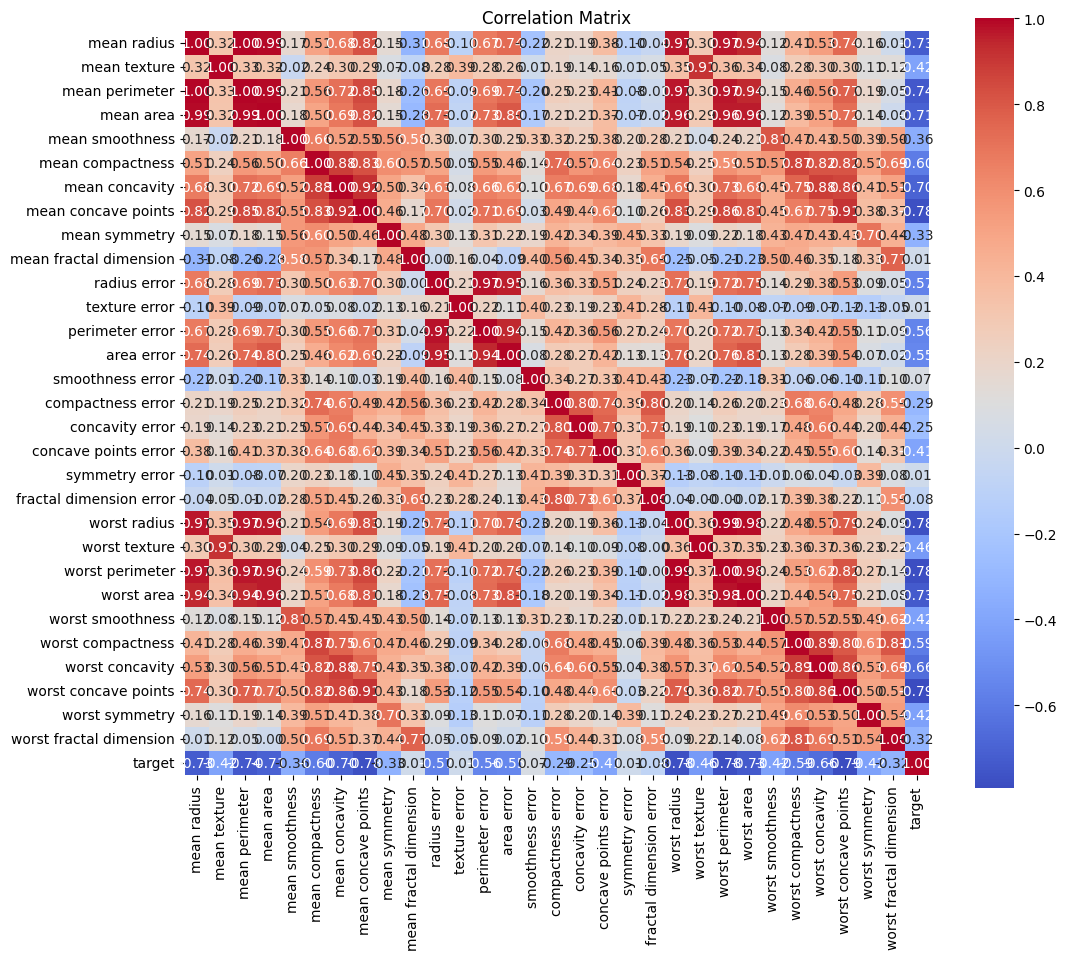

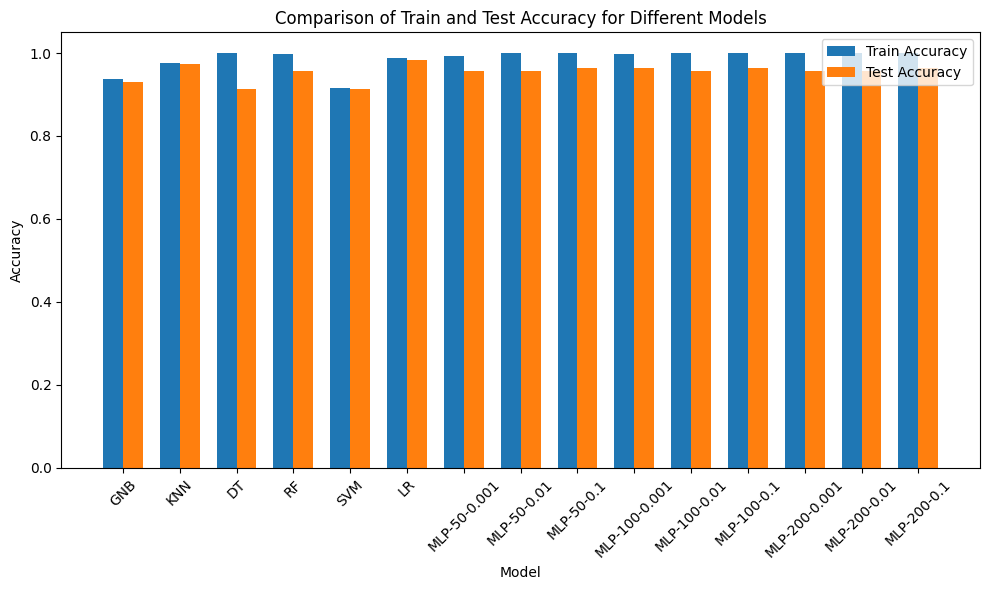

GNB - Cross-validated accuracy: 0.9319 ± 0.0044
KNN - Cross-validated accuracy: 0.9714 ± 0.0192
DT - Cross-validated accuracy: 0.9099 ± 0.0189
RF - Cross-validated accuracy: 0.9604 ± 0.0192
SVM - Cross-validated accuracy: 0.8967 ± 0.0215
LR - Cross-validated accuracy: 0.9802 ± 0.0128
بهترین پارامترها برای Logistic Regression: {'C': 0.1}
جمع‌بندی نتایج:
            Model  Train Accuracy  Test Accuracy  Precision    Recall  \
0             GNB        0.938462       0.929825   0.944444  0.944444   
1             KNN        0.975824       0.973684   0.972603  0.986111   
2              DT        1.000000       0.912281   0.955882  0.902778   
3              RF        0.997802       0.956140   0.958904  0.972222   
4             SVM        0.916484       0.912281   0.878049  1.000000   
5              LR        0.989011       0.982456   0.986111  0.986111   
6    MLP-50-0.001        0.993407       0.956140   0.985507  0.944444   
7     MLP-50-0.01        1.000000       0.956140   0.985507  

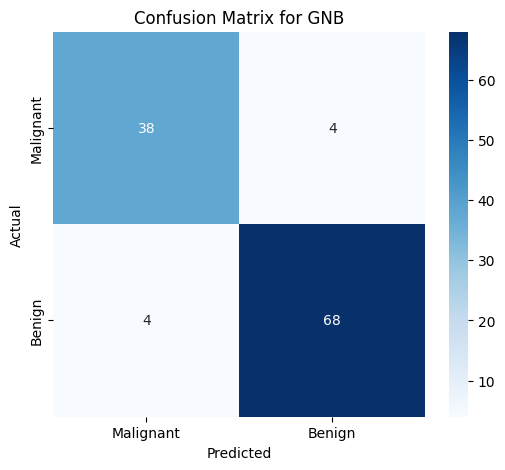

GNB - TN: 38, FP: 4, FN: 4, TP: 68
نگرش مثبت (Recall): 0.9444
نگرش منفی (Specificity): 0.9048


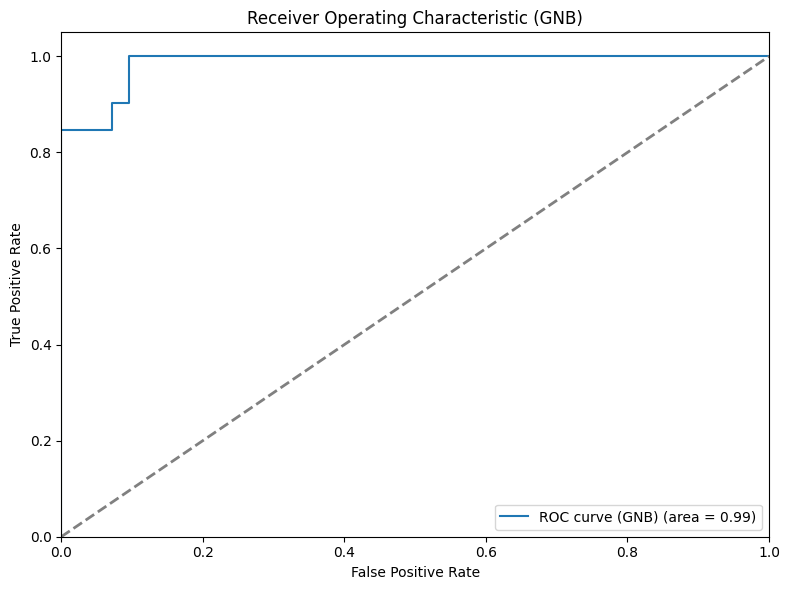

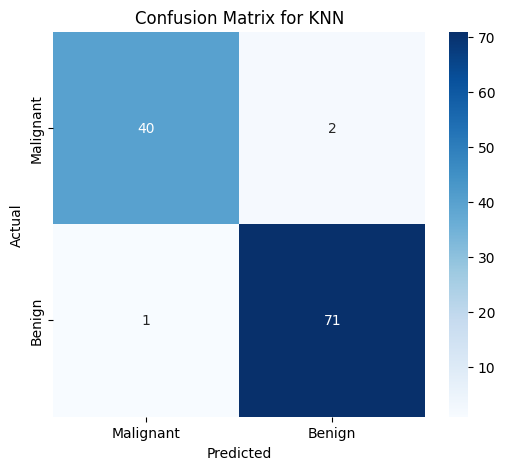

KNN - TN: 40, FP: 2, FN: 1, TP: 71
نگرش مثبت (Recall): 0.9861
نگرش منفی (Specificity): 0.9524


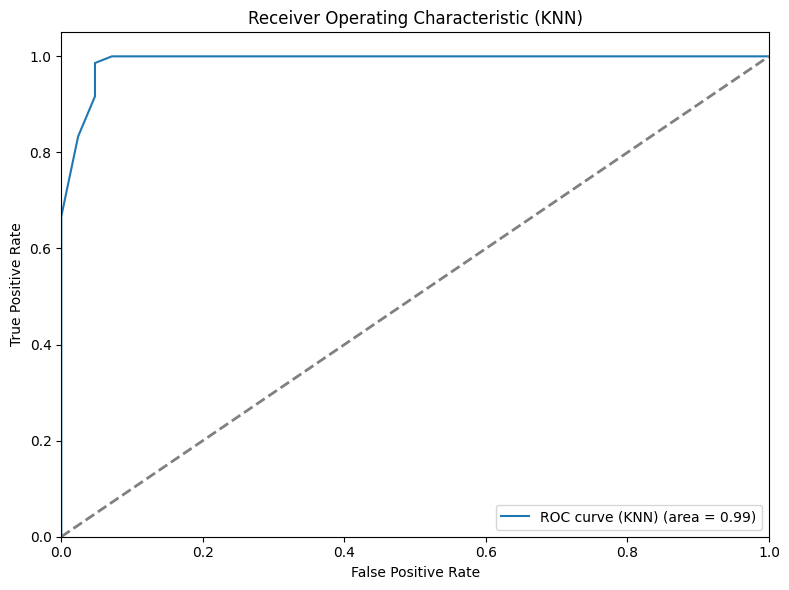

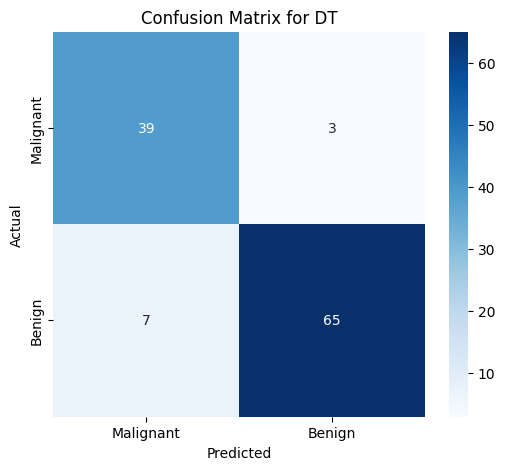

DT - TN: 39, FP: 3, FN: 7, TP: 65
نگرش مثبت (Recall): 0.9028
نگرش منفی (Specificity): 0.9286


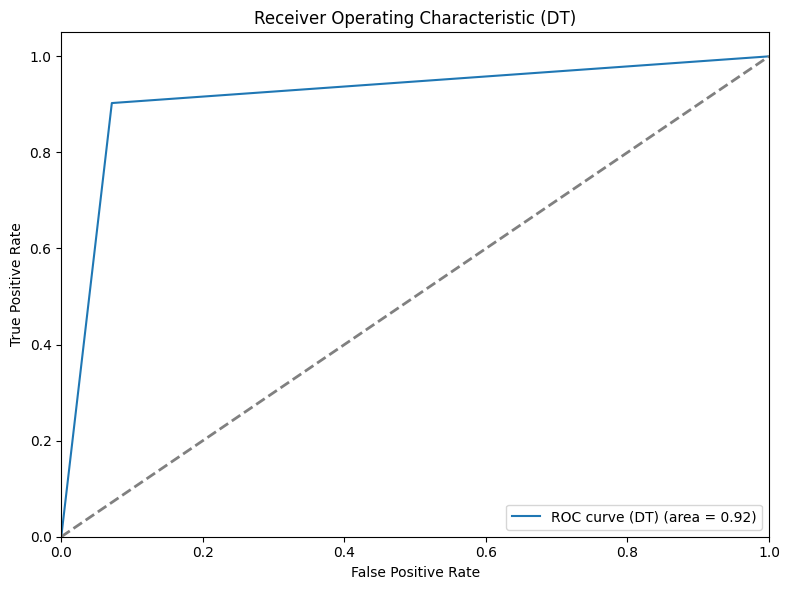

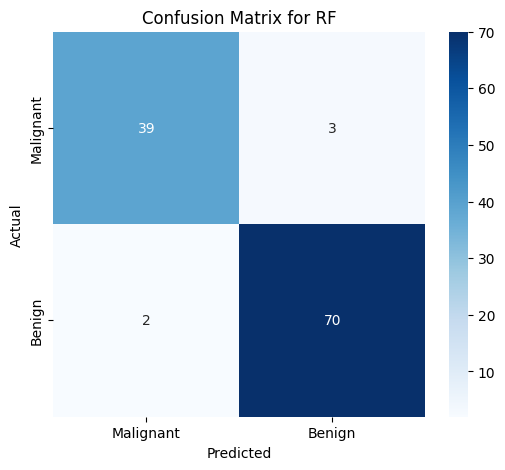

RF - TN: 39, FP: 3, FN: 2, TP: 70
نگرش مثبت (Recall): 0.9722
نگرش منفی (Specificity): 0.9286


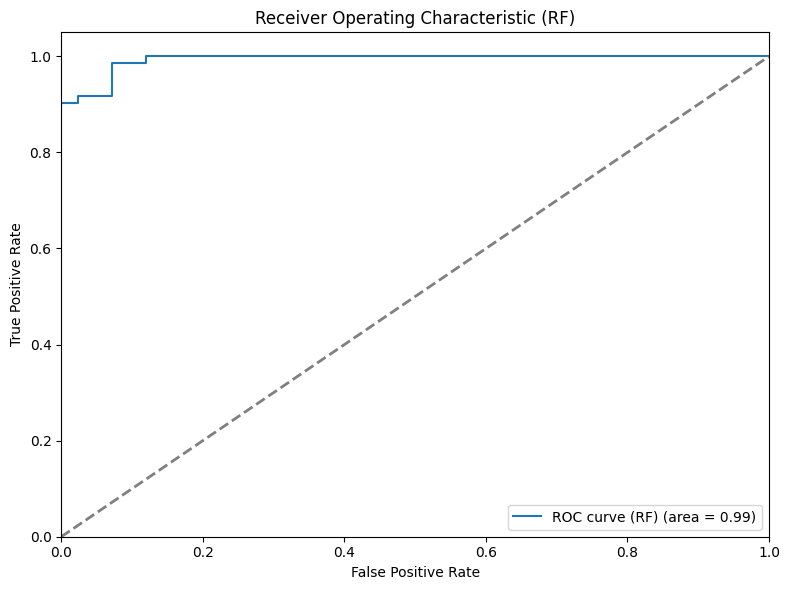

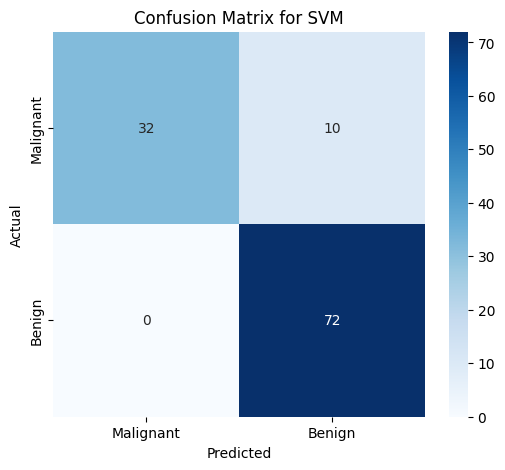

SVM - TN: 32, FP: 10, FN: 0, TP: 72
نگرش مثبت (Recall): 1.0000
نگرش منفی (Specificity): 0.7619


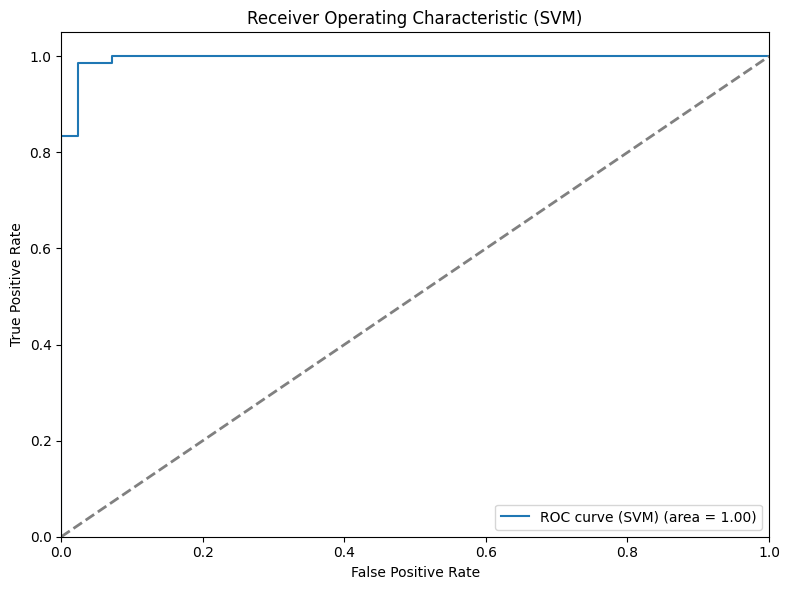

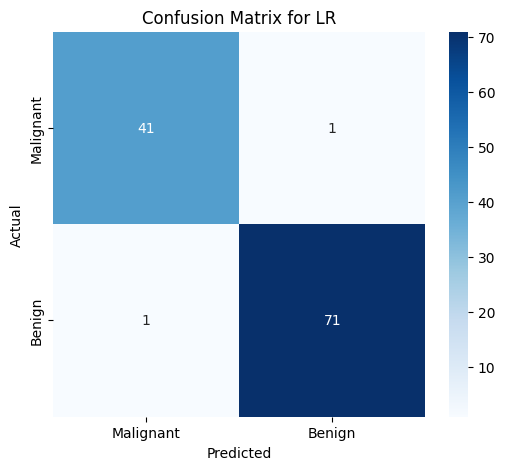

LR - TN: 41, FP: 1, FN: 1, TP: 71
نگرش مثبت (Recall): 0.9861
نگرش منفی (Specificity): 0.9762


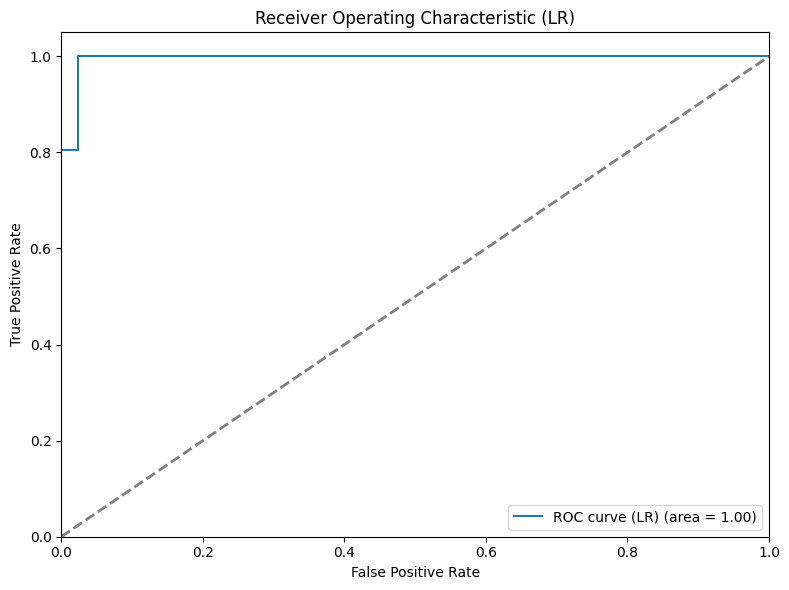

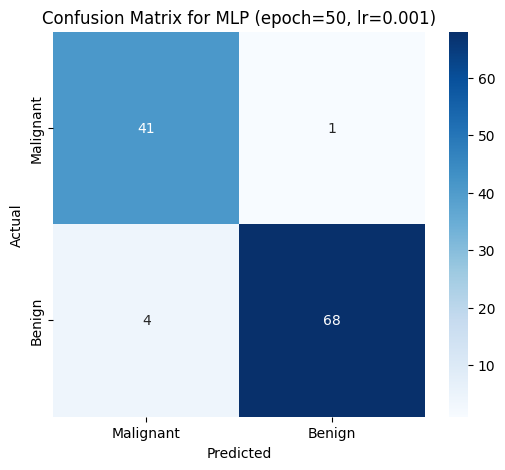

MLP (epoch=50, lr=0.001) - TN: 41, FP: 1, FN: 4, TP: 68
Recall (Sensitivity): 0.9444
Specificity: 0.9762


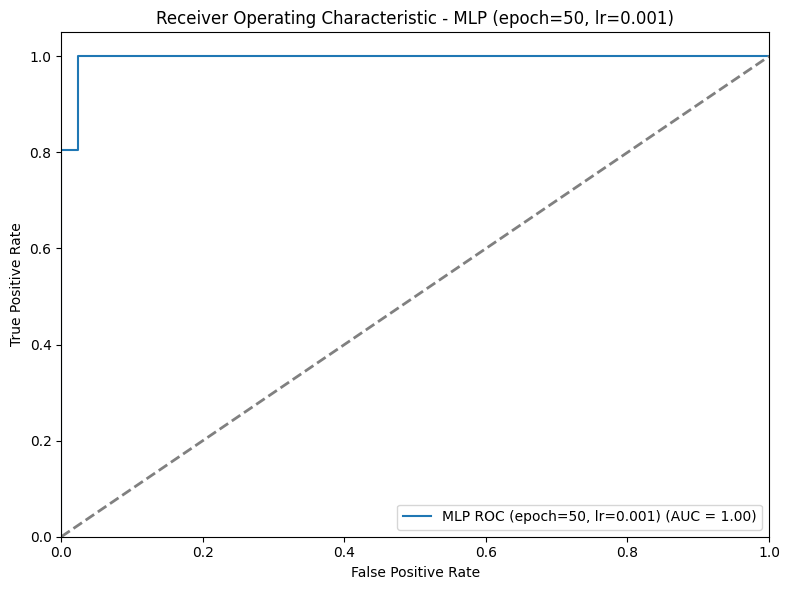

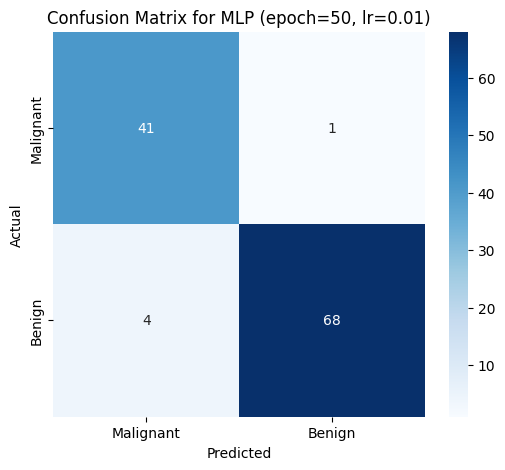

MLP (epoch=50, lr=0.01) - TN: 41, FP: 1, FN: 4, TP: 68
Recall (Sensitivity): 0.9444
Specificity: 0.9762


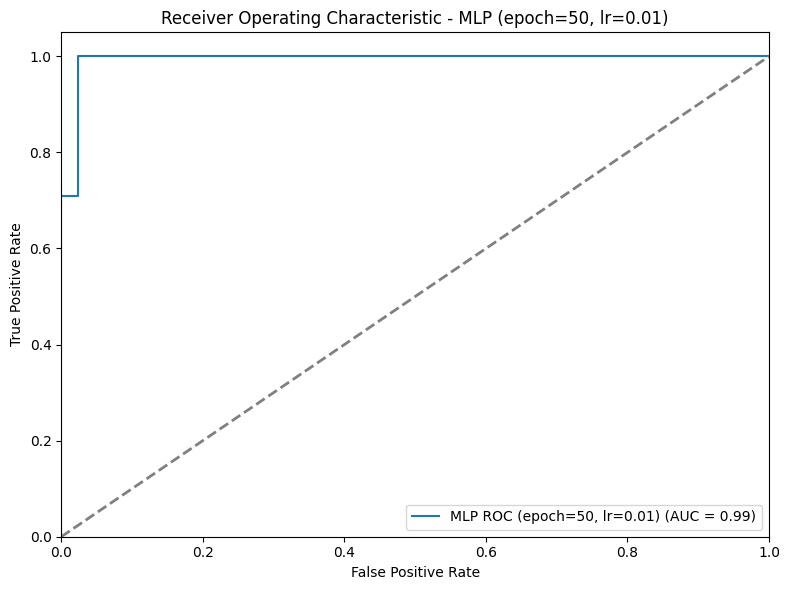

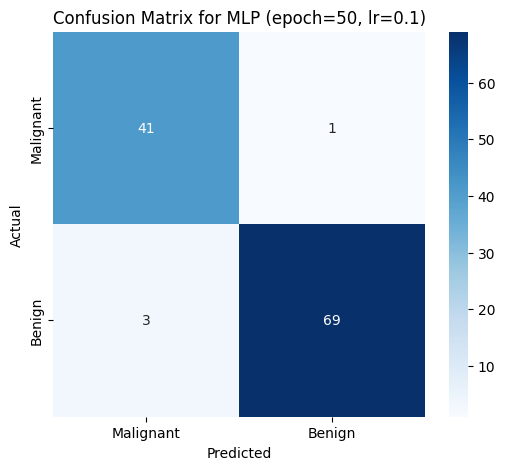

MLP (epoch=50, lr=0.1) - TN: 41, FP: 1, FN: 3, TP: 69
Recall (Sensitivity): 0.9583
Specificity: 0.9762


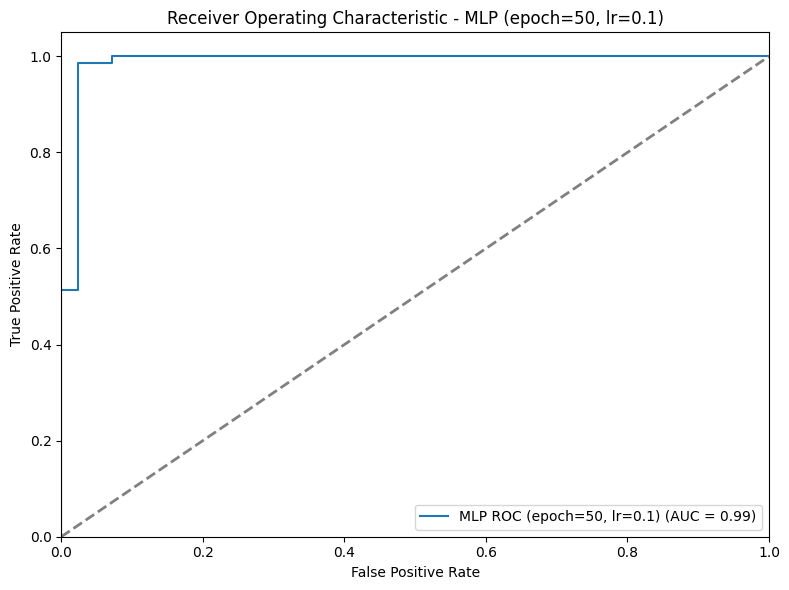

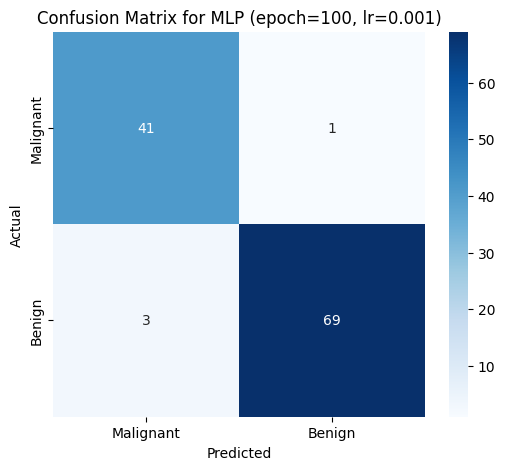

MLP (epoch=100, lr=0.001) - TN: 41, FP: 1, FN: 3, TP: 69
Recall (Sensitivity): 0.9583
Specificity: 0.9762


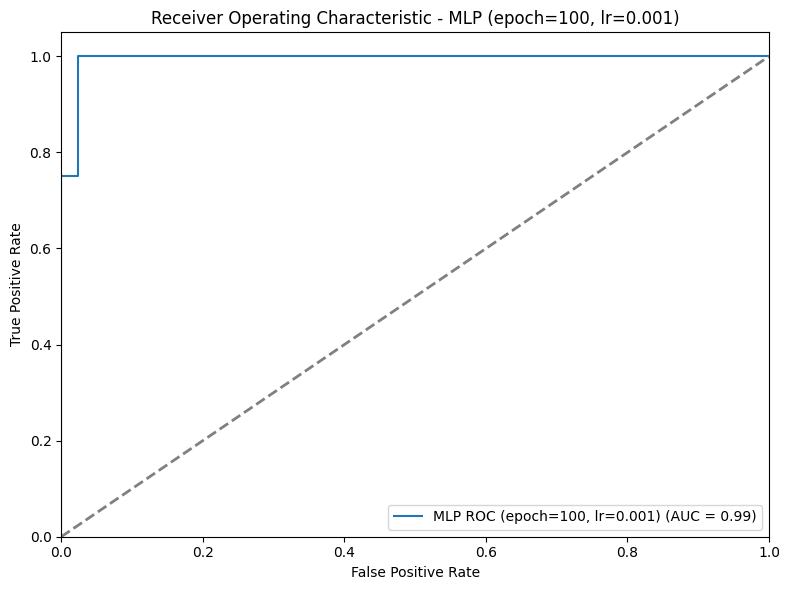

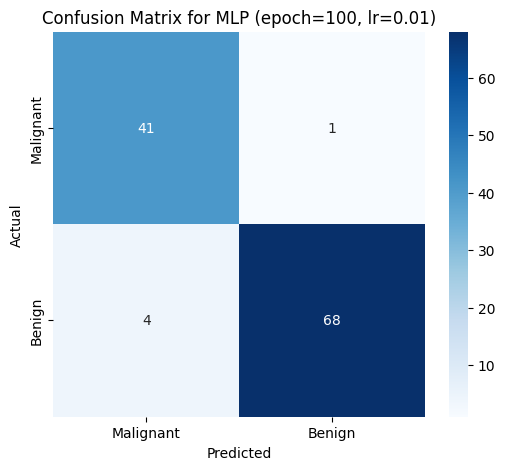

MLP (epoch=100, lr=0.01) - TN: 41, FP: 1, FN: 4, TP: 68
Recall (Sensitivity): 0.9444
Specificity: 0.9762


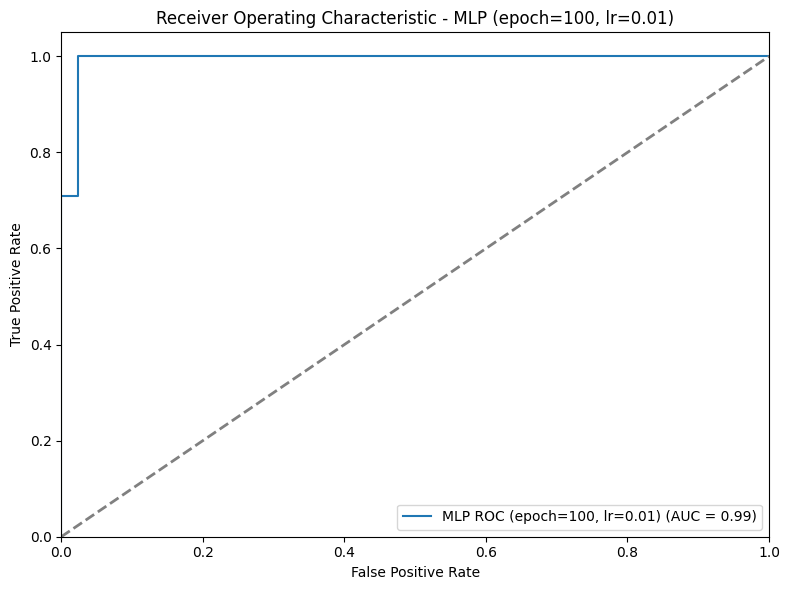

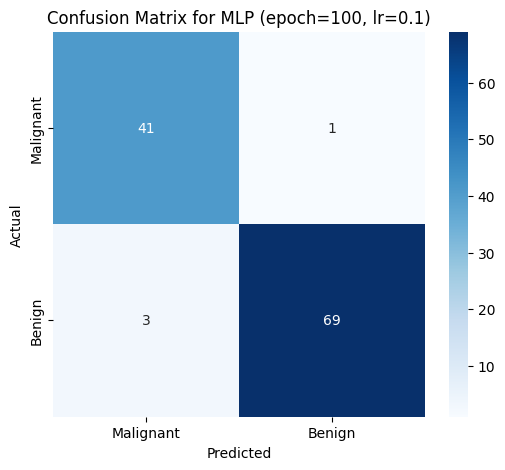

MLP (epoch=100, lr=0.1) - TN: 41, FP: 1, FN: 3, TP: 69
Recall (Sensitivity): 0.9583
Specificity: 0.9762


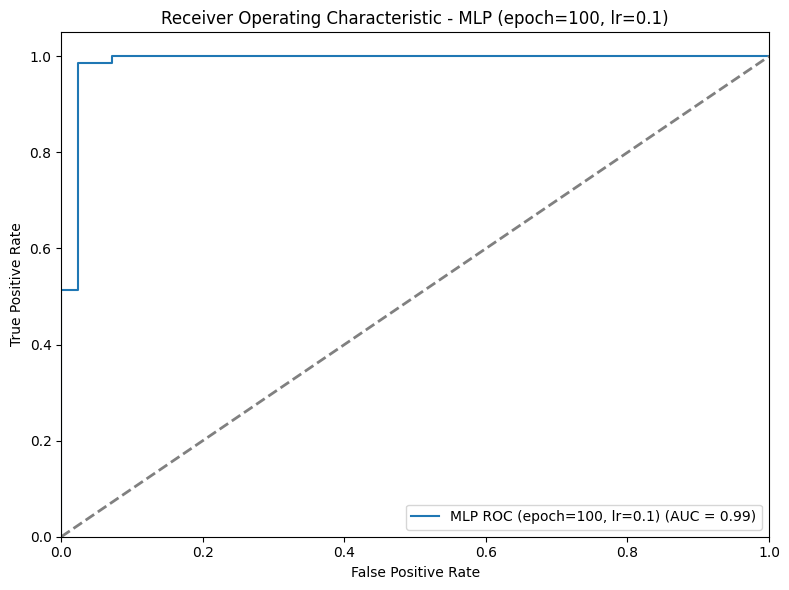

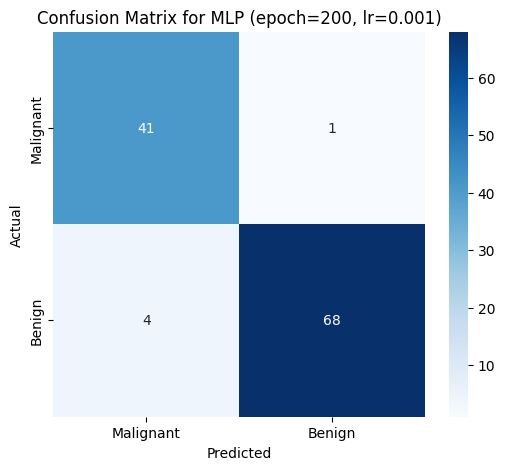

MLP (epoch=200, lr=0.001) - TN: 41, FP: 1, FN: 4, TP: 68
Recall (Sensitivity): 0.9444
Specificity: 0.9762


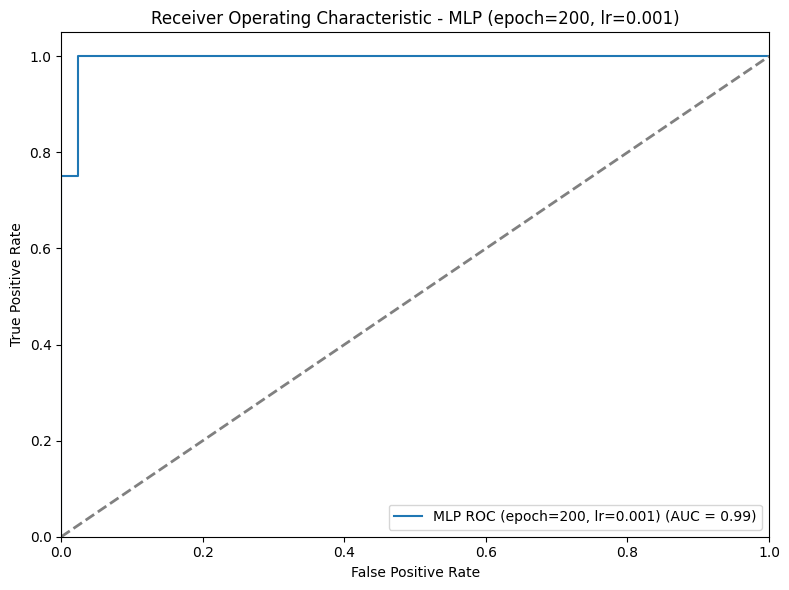

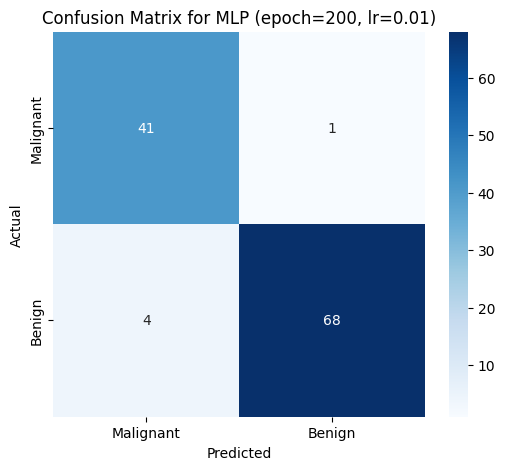

MLP (epoch=200, lr=0.01) - TN: 41, FP: 1, FN: 4, TP: 68
Recall (Sensitivity): 0.9444
Specificity: 0.9762


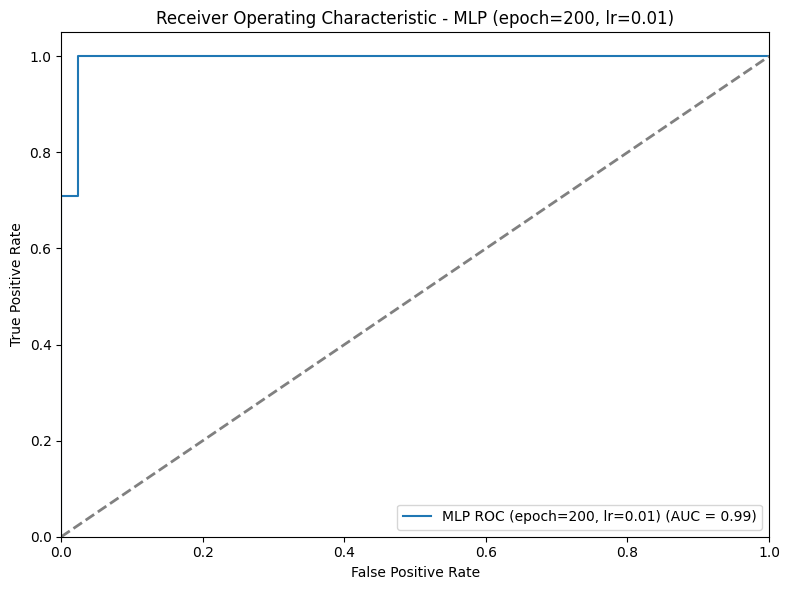

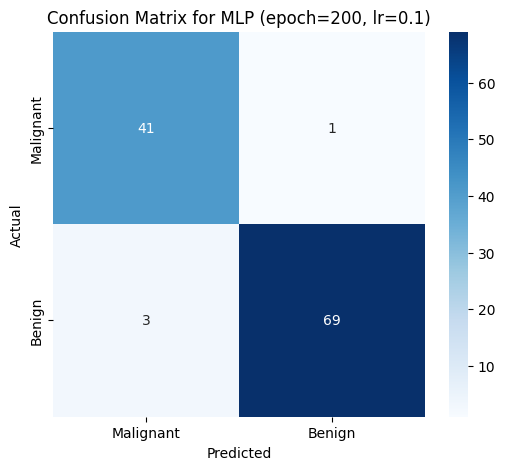

MLP (epoch=200, lr=0.1) - TN: 41, FP: 1, FN: 3, TP: 69
Recall (Sensitivity): 0.9583
Specificity: 0.9762


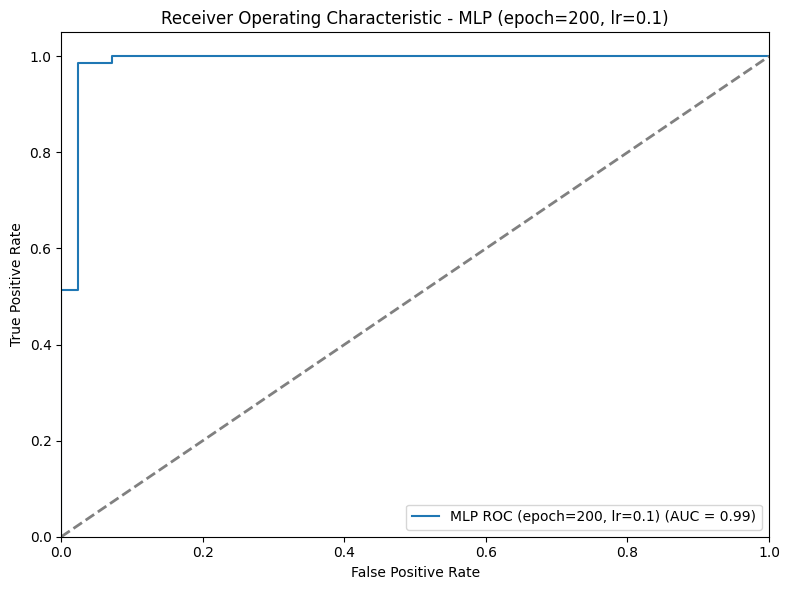

جمع‌بندی نتایج MLP با dataset size های مختلف (Test F1):
    train_size  epoch     lr  acc_train  acc_test  precision    recall  \
0          0.1     50  0.001   1.000000  0.921053   0.943662  0.930556   
1          0.1     50  0.010   1.000000  0.921053   0.943662  0.930556   
2          0.1     50  0.100   1.000000  0.903509   0.955224  0.888889   
3          0.1    100  0.001   1.000000  0.912281   0.942857  0.916667   
4          0.1    100  0.010   1.000000  0.921053   0.943662  0.930556   
5          0.1    100  0.100   1.000000  0.903509   0.955224  0.888889   
6          0.1    200  0.001   1.000000  0.921053   0.943662  0.930556   
7          0.1    200  0.010   1.000000  0.921053   0.943662  0.930556   
8          0.1    200  0.100   1.000000  0.903509   0.955224  0.888889   
9          0.3     50  0.001   1.000000  0.956140   0.971831  0.958333   
10         0.3     50  0.010   1.000000  0.947368   0.971429  0.944444   
11         0.3     50  0.100   1.000000  0.938596   0.97

In [6]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Load dataset
bc = load_breast_cancer()
data = pd.DataFrame(
    data=np.c_[bc['data'], bc['target']],
    columns=np.append(bc['feature_names'], 'target')
)

# Display dataset description
print(bc.DESCR)
print(data.head())
print(data.describe())

# نبود داده‌های گمشده
print(f"تعداد داده‌های گمشده: \n{data.isnull().sum()}")

# بررسی توزیع نرمال داده‌ها برای برخی ویژگی‌ها
sns.histplot(data['mean radius'], kde=True)
plt.title('normal distribution mean radius')
plt.show()

# PCA برای کاهش ابعاد
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_pca = pca.fit_transform(bc.data)
print(f"نسبت واریانس اصلی: {pca.explained_variance_ratio_}")

# Preprocessing
x_train, x_test, y_train, y_test = train_test_split(
    bc.data, bc.target, test_size=0.2, random_state=42, stratify=bc.target
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Classification and metrics
def calculate_metrics(y_train_local, y_test_local, y_pred_train, y_pred_test):
    acc_train = accuracy_score(y_true=y_train_local, y_pred=y_pred_train)
    acc_test = accuracy_score(y_true=y_test_local, y_pred=y_pred_test)
    p = precision_score(y_true=y_test_local, y_pred=y_pred_test)
    r = recall_score(y_true=y_test_local, y_pred=y_pred_test)
    f1 = f1_score(y_true=y_test_local, y_pred=y_pred_test)
    return acc_train, acc_test, p, r, f1

# Model training and evaluation
models = {
    "GNB": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=8, algorithm='kd_tree', leaf_size=28),
    "DT": DecisionTreeClassifier(max_depth=64, min_samples_split=2, criterion='gini', random_state=42),
    "RF": RandomForestClassifier(n_estimators=1000, max_depth=32, min_samples_split=4, random_state=42),
    "SVM": SVC(kernel='poly', probability=True, random_state=42),
    "LR": LogisticRegression(max_iter=5000, random_state=42)
}

# =========================
# MLP settings (epochs + learning rates)
# =========================
epochs = [50, 100, 200]
learning_rates = [0.001, 0.01, 0.1]

# =========================
# Dataset size experiments for MLP
# =========================
train_sizes = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]  # fraction of x_train/y_train used for training

mlp_results = {}               # key: (epoch, lr) -> metrics (full train size only; for backward-compat)
mlp_results_by_size = {}       # key: (train_size, epoch, lr) -> metrics

for size in train_sizes:
    if size < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=size, random_state=42)
        idx_sub, _ = next(sss.split(x_train, y_train))
        X_sub, y_sub = x_train[idx_sub], y_train[idx_sub]
    else:
        X_sub, y_sub = x_train, y_train

    for epoch in epochs:
        for lr in learning_rates:
            model = MLPClassifier(
                hidden_layer_sizes=256,
                activation='relu',
                solver='adam',
                batch_size=64,
                max_iter=epoch,
                learning_rate_init=lr,
                random_state=42
            )
            model.fit(X_sub, y_sub)

            y_pred_train_sub = model.predict(X_sub)
            y_pred_test = model.predict(x_test)

            metrics_tuple = calculate_metrics(y_sub, y_test, y_pred_train_sub, y_pred_test)
            mlp_results_by_size[(size, epoch, lr)] = metrics_tuple

            # keep also the "full train" results in the original structure (epoch, lr)
            if size == 1.0:
                mlp_results[(epoch, lr)] = metrics_tuple

# =========================
# Collecting results for classical models
# =========================
results = {}
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)
    results[name] = calculate_metrics(y_train, y_test, y_pred_train, y_pred_test)

# Adding MLP results (full train size) to main results
for (epoch, lr), value in mlp_results.items():
    results[f'MLP-{epoch}-{lr}'] = value

# Collecting results for visualization
acc_train = [res[0] for res in results.values()]
acc_test = [res[1] for res in results.values()]
precision = [res[2] for res in results.values()]
recall = [res[3] for res in results.values()]
f1_score_values = [res[4] for res in results.values()]
title = list(results.keys())

# =========================
# FIX: Generate enough colors for any number of bars
# =========================
colors = plt.cm.tab20(np.linspace(0, 1, len(title)))

# Visualization of metrics with color differentiation
plt.figure(figsize=(12, 8))

# Training Accuracy
plt.subplot(2, 2, 1)
plt.bar(title, acc_train, color=colors)
plt.title('Training Accuracy')
plt.xticks(rotation=45)

# Testing Accuracy
plt.subplot(2, 2, 2)
plt.bar(title, acc_test, color=colors)
plt.title('Testing Accuracy')
plt.xticks(rotation=45)

# Precision
plt.subplot(2, 2, 3)
plt.bar(title, precision, color=colors)
plt.title('Precision')
plt.xticks(rotation=45)

# Recall
plt.subplot(2, 2, 4)
plt.bar(title, recall, color=colors)
plt.title('Recall')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# =========================
# Plot effect of dataset size on MLP performance (Test F1)
# =========================
mlp_size_df = pd.DataFrame([
    {
        "train_size": k[0],
        "epoch": k[1],
        "lr": k[2],
        "acc_train": v[0],
        "acc_test": v[1],
        "precision": v[2],
        "recall": v[3],
        "f1": v[4]
    }
    for k, v in mlp_results_by_size.items()
])

plt.figure(figsize=(12, 7))
for (epoch, lr), grp in mlp_size_df.groupby(["epoch", "lr"]):
    grp_sorted = grp.sort_values("train_size")
    plt.plot(grp_sorted["train_size"], grp_sorted["f1"], marker='o', label=f"epoch={epoch}, lr={lr}")

plt.title("MLP Test F1 vs Train Dataset Size (for different epochs and learning rates)")
plt.xlabel("Train Dataset Size (fraction of training set)")
plt.ylabel("Test F1 Score")
plt.xticks(train_sizes)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Correlation Matrix
plt.figure(figsize=(12, 10))
correlation = data.corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

# Comparing Train vs Test Accuracy with color differentiation
plt.figure(figsize=(10, 6))
width = 0.35
x = np.arange(len(title))
plt.bar(x - width/2, acc_train, width, label='Train Accuracy')
plt.bar(x + width/2, acc_test, width, label='Test Accuracy')
plt.title('Comparison of Train and Test Accuracy for Different Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(ticks=x, labels=title, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Cross-validation to evaluate overfitting/underfitting
for name, model in models.items():
    cv_scores = cross_val_score(model, x_train, y_train, cv=5)
    print(f"{name} - Cross-validated accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Cross-validation and hyperparameter tuning example for Logistic Regression
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=5000, random_state=42), param_grid, cv=5)
grid.fit(x_train, y_train)
print(f'بهترین پارامترها برای Logistic Regression: {grid.best_params_}')

# جمع‌بندی نتایج نهایی
model_comparison = pd.DataFrame({
    'Model': title,
    'Train Accuracy': acc_train,
    'Test Accuracy': acc_test,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1_score_values
})

print("جمع‌بندی نتایج:")
print(model_comparison)

# Selecting the best model based on F1 Score
best_model = model_comparison.loc[model_comparison['F1 Score'].idxmax()]
print(f"بهترین مدل: {best_model['Model']} با F1 Score برابر {best_model['F1 Score']:.4f}")

# =========================
# Confusion Matrix and ROC Curve for each classical model
# =========================
for name, model in models.items():
    # IMPORTANT: model has been fit already above in results collection
    y_pred_test = model.predict(x_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap='Blues',
        xticklabels=['Malignant', 'Benign'],
        yticklabels=['Malignant', 'Benign']
    )
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # تجزیه و تحلیل ماتریس سردرگمی
    TN, FP, FN, TP = cm.ravel()
    print(f"{name} - TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")
    print(f"نگرش مثبت (Recall): {TP / (TP + FN):.4f}")
    print(f"نگرش منفی (Specificity): {TN / (TN + FP):.4f}")

    # ROC Curve and AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]
    else:
        y_prob = model.decision_function(x_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve ({name}) (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic ({name})')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# =========================
# Confusion Matrix and ROC Curve for MLP variants (epoch, lr) on full train size (size=1.0)
# =========================
for epoch in epochs:
    for lr in learning_rates:
        mlp_model = MLPClassifier(
            hidden_layer_sizes=256,
            activation='relu',
            solver='adam',
            batch_size=64,
            max_iter=epoch,
            learning_rate_init=lr,
            random_state=42
        )
        mlp_model.fit(x_train, y_train)

        y_pred_test = mlp_model.predict(x_test)

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred_test)
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm, annot=True, fmt="d", cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign']
        )
        plt.title(f'Confusion Matrix for MLP (epoch={epoch}, lr={lr})')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

        TN, FP, FN, TP = cm.ravel()
        print(f"MLP (epoch={epoch}, lr={lr}) - TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")
        print(f"Recall (Sensitivity): {TP / (TP + FN):.4f}")
        print(f"Specificity: {TN / (TN + FP):.4f}")

        # ROC Curve and AUC
        y_prob = mlp_model.predict_proba(x_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'MLP ROC (epoch={epoch}, lr={lr}) (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic - MLP (epoch={epoch}, lr={lr})')
        plt.legend(loc='lower right')
        plt.tight_layout()
        plt.show()

# (Optional) show the full MLP size experiment table
print("جمع‌بندی نتایج MLP با dataset size های مختلف (Test F1):")
print(mlp_size_df.sort_values(["train_size", "epoch", "lr"]))
